In [8]:
import torch
import json

with open('module_id_mapping.txt', 'r') as f:
    module_ip_mapping = json.load(f)


In [9]:
module_ip_mapping

{'layers.0.blocks.0.op': 140519993147696,
 'layers.0.blocks.1.op': 140519993153648,
 'layers.1.blocks.0.op': 140519993155328,
 'layers.1.blocks.1.op': 140519993156576,
 'layers.2.blocks.0.op': 140519993159456,
 'layers.2.blocks.1.op': 140519993161616,
 'layers.2.blocks.2.op': 140519993160656,
 'layers.2.blocks.3.op': 140519993477152,
 'layers.2.blocks.4.op': 140519993475712,
 'layers.2.blocks.5.op': 140519993158736,
 'layers.2.blocks.6.op': 140519993154032,
 'layers.2.blocks.7.op': 140519993157344,
 'layers.3.blocks.0.op': 140519993481520,
 'layers.3.blocks.1.op': 140519993477680}

In [10]:
import os
stacked_y_tensor = []
for tensor in os.listdir('.'):
    if tensor.endswith('.pt'):
        stacked_y_tensor.append(torch.load(tensor))

In [11]:
stacked_y_tensor = torch.concat(stacked_y_tensor, dim=0)

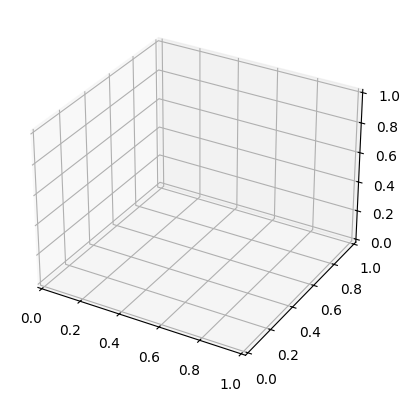

In [12]:
# Start draw 3D plot

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
mean_tensor = stacked_y_tensor.mean(dim=1, keepdim=True).cpu().numpy()

In [13]:
mean_tensor.shape

(5000, 1, 196)

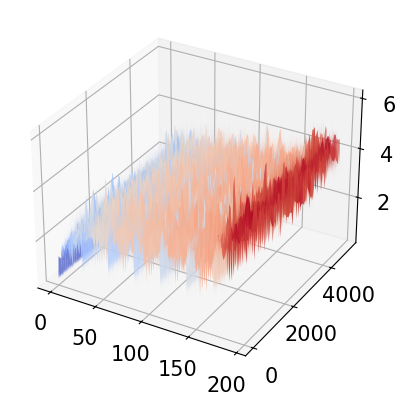

In [35]:
data = mean_tensor
data = np.abs(data.squeeze())
x = np.arange(data.shape[1])  # Length (196)
y = np.arange(data.shape[0])  # Data count (5000)
X, Y = np.meshgrid(x, y)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.zaxis.set_tick_params(labelsize=15)

# ax.set_xlabel('Sequence Length', fontsize=15)
# ax.set_ylabel('Data Point', fontsize=15)
# ax.set_zlabel('Mean Absolute Value of Inner Dimension', fontsize=15)
ax.plot_surface(X, Y,data, cmap='coolwarm', edgecolor='none', alpha=0.7)
plt.savefig('3d_plot.png', dpi=300)


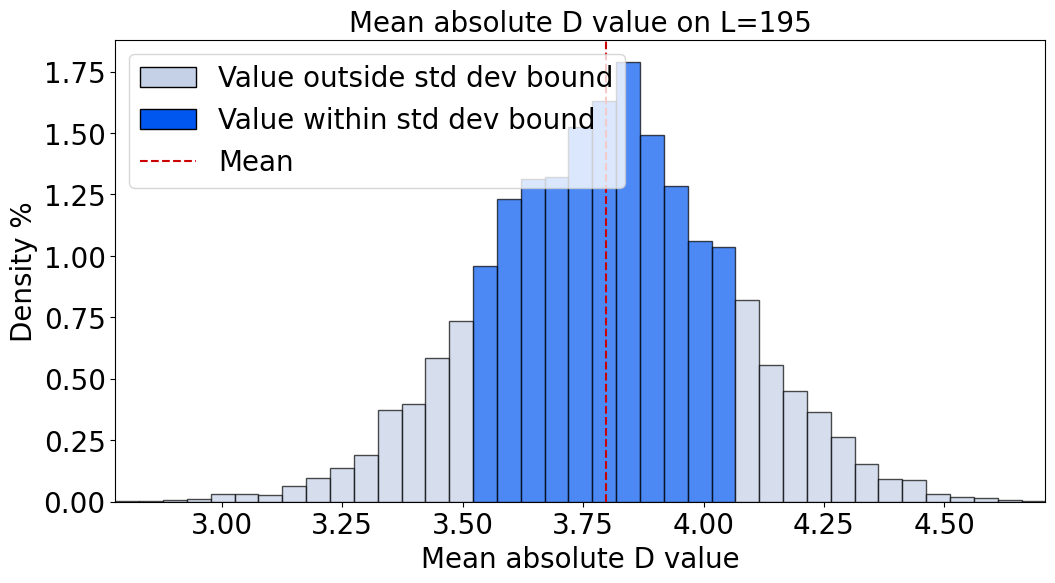

In [42]:
# Calculate statistics
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


for t in range(data.shape[1]):
    data_t = data[:, -1]
    mean = np.mean(data_t)
    std_dev = np.std(data_t)

    # Plotting
    plt.figure(figsize=(12, 6))
    upper_bound = mean + std_dev
    lower_bound = mean - std_dev
    
    bins = np.linspace(np.min(data_t), np.max(data_t), 40)

    # Plot histogram
    n, bins, patches = plt.hist(data_t, bins=bins, edgecolor='black', alpha=0.7, density=True)

    # Color bins based on bounds
    for patch, bin_center in zip(patches, 0.5 * (bins[:-1] + bins[1:])):
        if lower_bound <= bin_center <= upper_bound:
            patch.set_facecolor('#0057f0')  # Inside bounds color
        else:
            patch.set_facecolor('#c5d1e7')  # Outside bounds color
    
    # Plot mean line
    plt.axvline(mean, color='#cb0000', linestyle='--', linewidth=1.5, label='Mean')

    # Plot upper and lower bounds as lines
    # plt.axvline(upper_bound, color='#d87d7d', linestyle='--', linewidth=1.5, label='Mean + 1 Std Dev')
    # plt.axvline(lower_bound, color='#d87d7d', linestyle='--', linewidth=1.5, label='Mean - 1 Std Dev')
    # x_filtered = x[mask]
    # data_t_masked = np.where((data_t >= lower_bound) & (data_t <= upper_bound), data_t, np.nan)
    # data_t_unmasked = np.where((data_t < lower_bound) | (data_t > upper_bound), data_t, np.nan)
    # plt.plot(data_t, color='#c5d1e7', linewidth=1.5)
    # plt.plot(data_t_masked, label='Points within mean ± std_dev',linewidth=1.5, color='#0057f0')
    # plt.axhline(mean, color='#cb0000', linestyle='--', linewidth=1.5, label='Mean')


    # std_upper_1 = plt.plot(range(len(data_t)), upper_bound * np.ones(len(data_t)), color='#d87d7d', linestyle='--', linewidth=1.5)
    # std_lower_1 = plt.plot(range(len(data_t)), lower_bound * np.ones(len(data_t)), color='#d87d7d', linestyle='--', linewidth=1.5)

    # std_upper_1 = plt.plot(range(len(data_t)), (upper_bound + std_dev) * np.ones(len(data_t)), color='#e3caca', linestyle='--', linewidth=1.5)
    # std_lower_1 = plt.plot(range(len(data_t)), (lower_bound - std_dev) * np.ones(len(data_t)), color='#e3caca', linestyle='--', linewidth=1.5)

    # Fill areas for 1 and 2 standard deviations

    # custom_legend = [
    #     Line2D([0], [0], color='#c5d1e7', linewidth=1.5, label='Data'),
    #     Line2D([0], [0], color='#0057f0', linewidth=1.5, label='Data points within mean ± std_dev'),
    #     Line2D([0], [0], color='#cb0000', linestyle='--', linewidth=1.5, label='Mean'),
    #     Line2D([0], [0], color='#d87d7d', linewidth=1.5, linestyle='--', label='mean ± 1 * std_dev'),
    #     # Line2D([0], [0], color='lightgreen', linewidth=1.5, linestyle='--', label='mean ± 2 * std_dev')
    # ]

    
    # plt.ylim(mean - 5 * std_dev, mean + 5 * std_dev)
    plt.margins(x=0)

    custom_legend = [
        Patch(facecolor='#c5d1e7', edgecolor='black', label='Value outside std dev bound'),
        Patch(facecolor='#0057f0', edgecolor='black', label='Value within std dev bound'),
        Line2D([0], [0], color='#cb0000', linestyle='--', linewidth=1.5, label='Mean'),
        # Line2D([0], [0], color='#d87d7d', linestyle='--', linewidth=1.5, label='Mean ± 1 Std Dev'),
    ]
    # Add labels and title
    plt.title('Mean absolute D value on L=195', fontsize=20)
    plt.xlabel('Mean absolute D value', fontsize=20)
    plt.ylabel('Density %', fontsize=20)
    plt.legend(handles=custom_legend, fontsize=20)
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # plt.legend(custom_lines, ['Mean ± 1 Std Dev'])
    plt.savefig(f'mean_absolute_D_value.png', dpi=500)
    # plt.close()
    break


In [10]:
plt.show()